In [3]:
# Cài đặt thư viện
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import matplotlib.pyplot as plt

In [4]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Train:", x_train.shape)
print("Test:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28)
Test: (10000, 28, 28)


In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

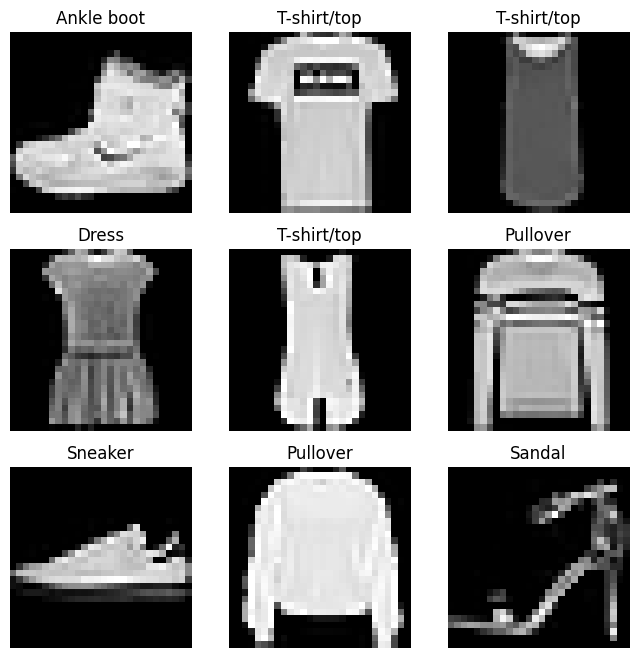

In [7]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.7887 - loss: 0.5822 - val_accuracy: 0.8378 - val_loss: 0.4303
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8405 - loss: 0.4311 - val_accuracy: 0.8615 - val_loss: 0.3878
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8550 - loss: 0.3945 - val_accuracy: 0.8675 - val_loss: 0.3580
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8645 - loss: 0.3716 - val_accuracy: 0.8700 - val_loss: 0.3601
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8704 - loss: 0.3533 - val_accuracy: 0.8794 - val_loss: 0.3321
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8758 - loss: 0.3382 - val_accuracy: 0.8793 - val_loss: 0.3259
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8783 - loss: 0.3315 - val_accuracy: 0.8816 - val_loss: 0.3370
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8820 - loss: 0.3208 - 

In [12]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8782 - loss: 0.3460
Loss: 0.3460068702697754
Accuracy: 0.8781999945640564


In [13]:
predictions = model.predict(x_test)

print("Dự đoán:", class_names[predictions[0].argmax()])
print("Đáp án :", class_names[y_test[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Dự đoán: Ankle boot
Đáp án : Ankle boot


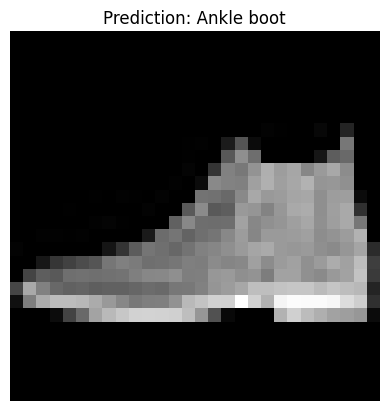

In [14]:
plt.imshow(x_test[0], cmap='gray')
plt.title("Prediction: " + class_names[predictions[0].argmax()])
plt.axis("off")
plt.show()

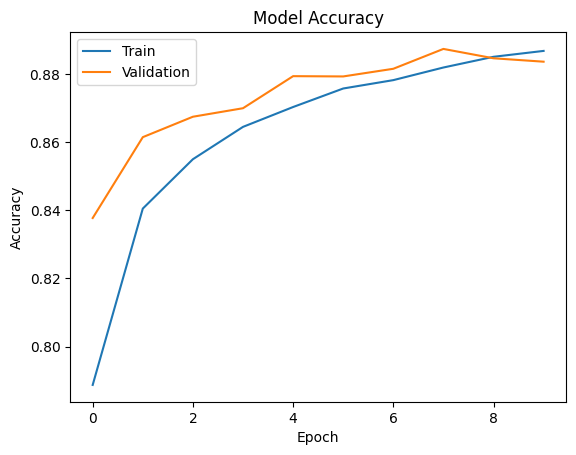

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

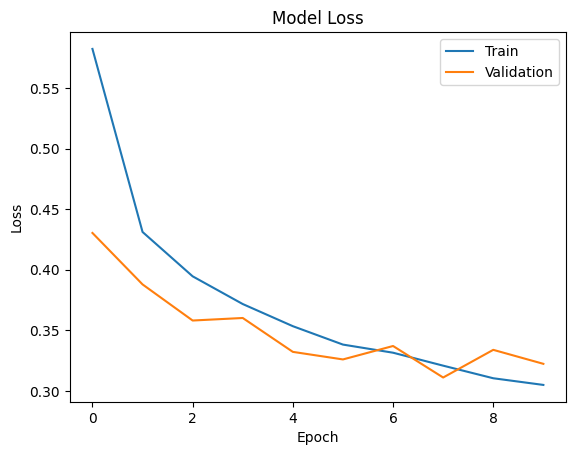

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()